Group members

Kunal Sharma ACE081BCT041

Niraj Shah   ACE081BCT045

# Student Habits vs Academic Performance using dataset preprocessing
**Overview**                                                                   
The project is a demonstatration of various techniques utilized in order to perform logistic regression and the dataset is utilized in order to perform eda,feature engineering,model training,model evaluation etc.
logistics regression was chosen in this project as the computation power required is low and since the target feature exam_score is in numerical format it is easier to calculate.

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [137]:
df = pd.read_csv('/content/project/student_habits_performance.csv')
df = pd.DataFrame(df)

In [138]:
df.head(10)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
5,S1005,24,Male,7.2,1.3,0.0,No,82.9,7.4,Fair,1,Master,Average,4,No,100.0
6,S1006,21,Female,5.6,1.5,1.4,Yes,85.8,6.5,Good,2,Master,Poor,4,No,89.8
7,S1007,21,Female,4.3,1.0,2.0,Yes,77.7,4.6,Fair,0,Bachelor,Average,8,No,72.6
8,S1008,23,Female,4.4,2.2,1.7,No,100.0,7.1,Good,3,Bachelor,Good,1,No,78.9
9,S1009,18,Female,4.8,3.1,1.3,No,95.4,7.5,Good,5,Bachelor,Good,10,Yes,100.0


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [140]:
df.isna().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


In [141]:
df2 = df.drop('student_id', axis=1)
df2.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [142]:
df['parental_education_level'].describe()

,parental_education_level
count,909
unique,3
top,High School
freq,392


In [143]:
df['parental_education_level'] = df['parental_education_level'].fillna(df['parental_education_level'].mode()[0])

In [144]:
df.isna().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


In [145]:
df

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


<Axes: ylabel='Gender'>

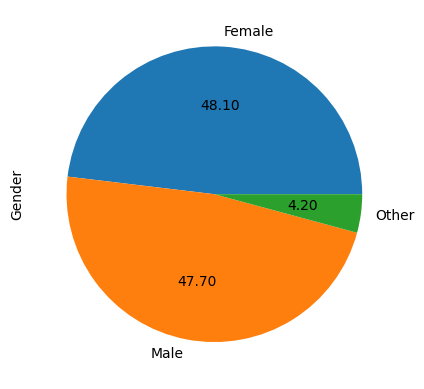

In [146]:
df['gender'].value_counts().plot(kind='pie',autopct='%0.2f',ylabel='Gender')

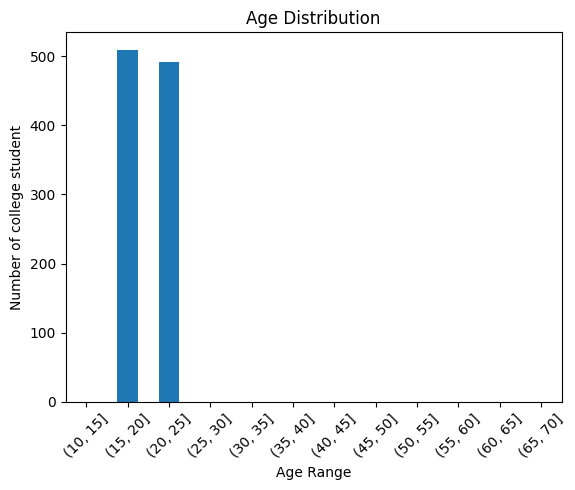

In [147]:
df['Age_Group'] = pd.cut(df['age'], bins=range(10, 71, 5))
age_counts = df['Age_Group'].value_counts().sort_index()
age_counts.plot(kind='bar')

plt.xlabel("Age Range")
plt.ylabel("Number of college student")
plt.title('Age Distribution')
plt.xticks(rotation=45)
plt.show()


<Axes: ylabel='exercise_frequency'>

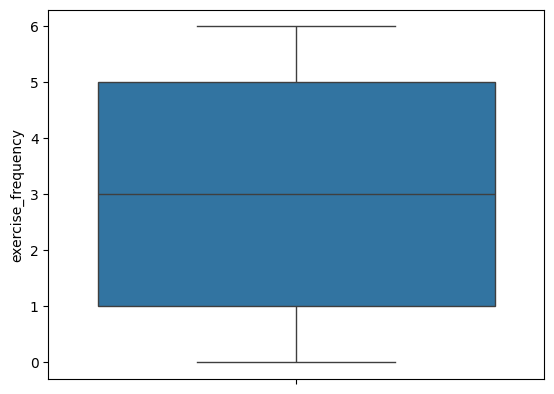

In [148]:
sns.boxplot(df['exercise_frequency'])

<Axes: ylabel='exam_score'>

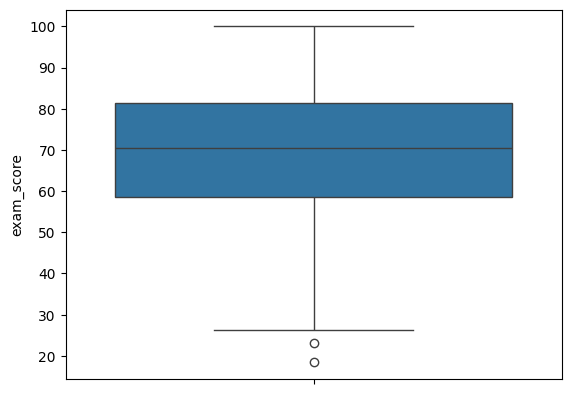

In [149]:
sns.boxplot(df['exam_score'])

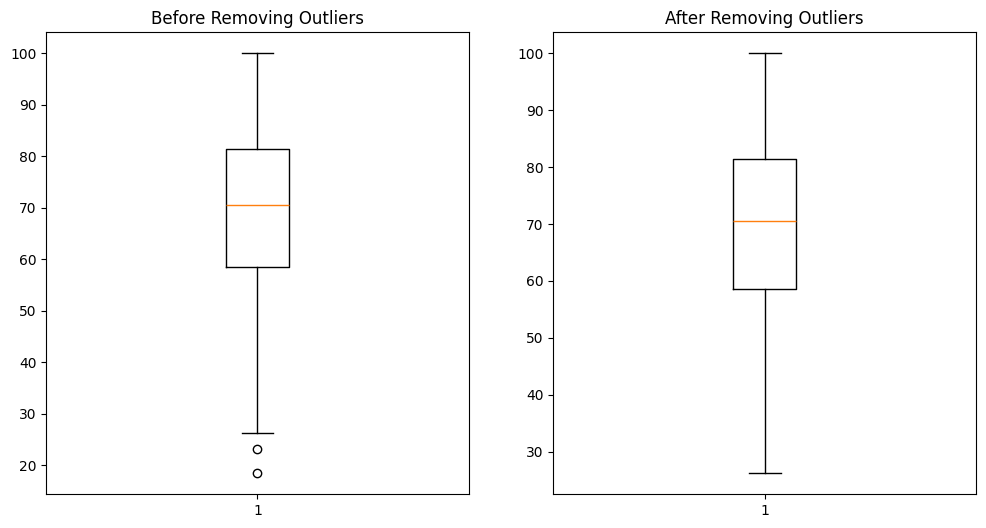

In [150]:
Q1 = df['exam_score'].quantile(0.25)
Q3 = df['exam_score'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_filtered = df[(df['exam_score'] >= lower_bound) & (df['exam_score'] <= upper_bound)]

# Plot before and after removing outliers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.boxplot(df['exam_score'])
ax1.set_title("Before Removing Outliers")

ax2.boxplot(df_filtered['exam_score'])
ax2.set_title("After Removing Outliers")

plt.show()

In [151]:
import pandas as pd
df['parental_education_level'] = df['parental_education_level'].fillna(df['parental_education_level'].mode()[0])  # Most frequent value
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])  # Most frequent value
print(df)

    student_id  age  gender  study_hours_per_day  social_media_hours  \
0        S1000   23  Female                  0.0                 1.2   
1        S1001   20  Female                  6.9                 2.8   
2        S1002   21    Male                  1.4                 3.1   
3        S1003   23  Female                  1.0                 3.9   
4        S1004   19  Female                  5.0                 4.4   
..         ...  ...     ...                  ...                 ...   
995      S1995   21  Female                  2.6                 0.5   
996      S1996   17  Female                  2.9                 1.0   
997      S1997   20    Male                  3.0                 2.6   
998      S1998   24    Male                  5.4                 4.1   
999      S1999   19  Female                  4.3                 2.9   

     netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0              1.1            No                   85.0        

In [152]:
from sklearn.preprocessing import MinMaxScaler
df = df_filtered
# For score
df['exam_score'] = MinMaxScaler().fit_transform(df[['exam_score']])

/tmp/ipykernel_330/4154470066.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['exam_score'] = MinMaxScaler().fit_transform(df[['exam_score']])


In [153]:
df.to_csv('up_studentdetail.csv')

In [154]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/project/up_studentdetail.csv')

# Select only numeric features
df_numeric = df.select_dtypes(include=np.number)

# Separate features and target if needed
# For example, target column is 'exam_score'
X = df_numeric.drop(columns=['exam_score'], errors='exam_score')  # features
y = df_numeric['exam_score'] if 'exam_score' in df_numeric.columns else None

# Handle missing values by imputing mean
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


In [155]:
df

,Unnamed: 0,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,Age_Group
0,0,S1000,0.857143,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,0.406504,"(20, 25]"
1,1,S1001,0.428571,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,1.000000,"(15, 20]"
2,2,S1002,0.571429,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,0.109756,"(20, 25]"
3,3,S1003,0.857143,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,0.008130,"(20, 25]"
4,4,S1004,0.285714,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,0.544715,"(15, 20]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,995,S1995,0.571429,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,0.676152,"(20, 25]"
994,996,S1996,0.000000,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,0.537940,"(15, 20]"
995,997,S1997,0.428571,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,0.517615,"(15, 20]"
996,998,S1998,1.000000,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,0.589431,"(20, 25]"


In [156]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio for each component:")
print(explained_variance)

Explained variance ratio for each component:
[0.12798329 0.12045955 0.11595527 0.11260664 0.10996385 0.10721459
 0.10475415 0.10224823 0.09881442]


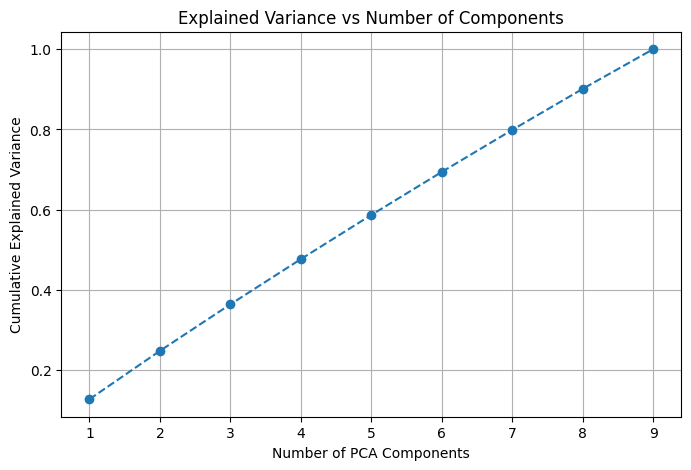

Number of components to explain 95% variance: 9


In [157]:
# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.grid(True)
plt.show()

# Choose number of components to explain 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components to explain 95% variance: {n_components_95}")

In [158]:
# Apply PCA with optimal number of components
pca_final = PCA(n_components=n_components_95)
X_pca_final = pca_final.fit_transform(X_scaled)

print(f"Shape of original features: {X_scaled.shape}")
print(f"Shape after PCA: {X_pca_final.shape}")

Shape of original features: (998, 9)
Shape after PCA: (998, 9)


Learned parameters (theta): [ 0.37168124 -0.00421149  0.00273903  0.11876014 -0.02235642 -0.0236793
  0.01452316  0.01906968  0.02023103  0.04327039]
MSE train: 0.0589
MSE test: 0.0616


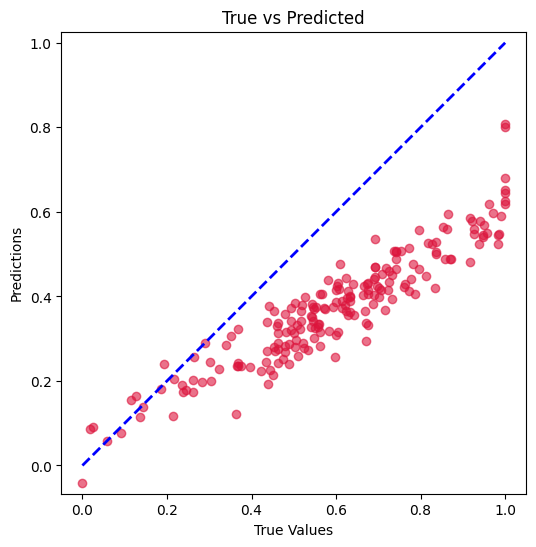

In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Load and preprocess dataset

df = pd.read_csv('updated-data2.csv')

# Select numeric features
df_numeric = df.select_dtypes(include=np.number)

# Separate features and target (replace 'exam_score' with your target column)
target_column = 'exam_score' if 'exam_score' in df_numeric.columns else df_numeric.columns[-1]
X = df_numeric.drop(columns=[target_column])
y = df_numeric[target_column]

# Add intercept column
X_scaled = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y.values, test_size=0.2, random_state=42)


# Gradient Descent for Linear Regression

def gradient_descent(X, y, lr=0.001, max_iter=1000):
    theta = np.zeros(X.shape[1])
    m = X.shape[0]

    for i in range(max_iter):
        y_hat = X @ theta
        grad = (X.T @ (y_hat - y)) / m
        theta -= lr * grad

    return theta

# Train model
theta = gradient_descent(X_train, y_train, lr=0.001, max_iter=1000)
print("Learned parameters (theta):", theta)

# Predictions and Evaluation

def mse(y_pred, y_true):
    return ((y_pred - y_true)**2).mean()

# Training MSE
y_train_pred = X_train @ theta
mse_train = mse(y_train_pred, y_train)
print(f"MSE train: {mse_train:.4f}")

# Testing MSE
y_test_pred = X_test @ theta
mse_test = mse(y_test_pred, y_test)
print(f"MSE test: {mse_test:.4f}")

# Visualize Predictions
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, c='crimson', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', linewidth=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted')
plt.axis('equal')
plt.show()

In [160]:
X_train[0]
X_test[0]
print('Sample value test -->',X_test[0] @ theta)

print('predicted value -->',y_test[0])

Sample value test --> 0.8008444342940384
predicted value --> 1.0


In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/project/up_studentdetail.csv")
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
from sklearn.preprocessing import StandardScaler

# Reshape for scaler
exam_score = df['exam_score'].values.reshape(-1, 1)

# Standardize exam_score
scaler = StandardScaler()
exam_score_scaled = scaler.fit_transform(exam_score)

# Apply sigmoid
exam_score_sigmoid = sigmoid(exam_score_scaled)

# Add to dataframe
df['exam_score_sigmoid'] = exam_score_sigmoid

print(df[['exam_score', 'exam_score_sigmoid']].head())

   exam_score  exam_score_sigmoid
0    0.406504            0.308802
1    1.000000            0.859184
2    0.109756            0.107854
3    0.008130            0.071724
4    0.544715            0.450926


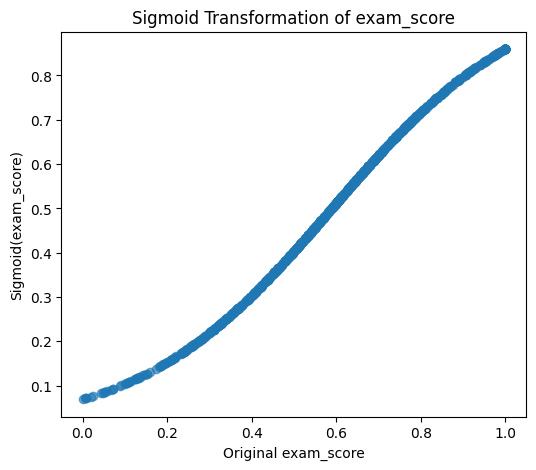

In [162]:
plt.figure(figsize=(6,5))
plt.scatter(df['exam_score'], df['exam_score_sigmoid'], alpha=0.6)
plt.xlabel("Original exam_score")
plt.ylabel("Sigmoid(exam_score)")
plt.title("Sigmoid Transformation of exam_score")
plt.show()

In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("/content/project/up_studentdetail.csv")

# Define sigmoid + derivative
def sigmoid(x, deriv=False):
    sig = 1 / (1 + np.exp(-x))
    if deriv:
        return sig * (1 - sig)
    return sig

# Scale exam_score (IMPORTANT)
exam_score = df["exam_score"].values.reshape(-1, 1)

scaler = StandardScaler()
exam_score_scaled = scaler.fit_transform(exam_score).flatten()

# Apply sigmoid + derivative
exam_score_sigmoid = sigmoid(exam_score_scaled)
exam_score_deriv = sigmoid(exam_score_scaled, deriv=True)

# Store in dataframe
df["exam_score_sigmoid"] = exam_score_sigmoid
df["exam_score_sigmoid_derivative"] = exam_score_deriv

print(df[["exam_score", "exam_score_sigmoid", "exam_score_sigmoid_derivative"]].head())

   exam_score  exam_score_sigmoid  exam_score_sigmoid_derivative
0    0.406504            0.308802                       0.213443
1    1.000000            0.859184                       0.120987
2    0.109756            0.107854                       0.096221
3    0.008130            0.071724                       0.066580
4    0.544715            0.450926                       0.247592


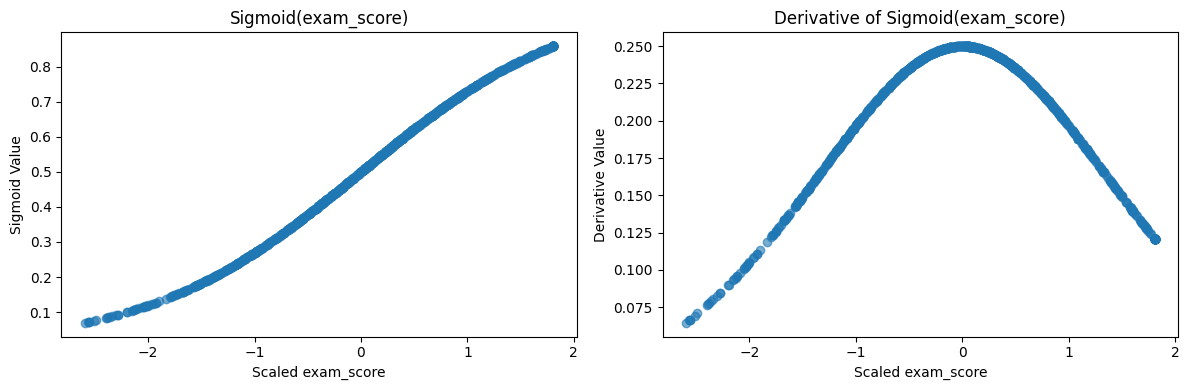

In [164]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Sigmoid plot
ax[0].scatter(exam_score_scaled, exam_score_sigmoid, alpha=0.6)
ax[0].set_title("Sigmoid(exam_score)")
ax[0].set_xlabel("Scaled exam_score")
ax[0].set_ylabel("Sigmoid Value")

# Derivative plot
ax[1].scatter(exam_score_scaled, exam_score_deriv, alpha=0.6)
ax[1].set_title("Derivative of Sigmoid(exam_score)")
ax[1].set_xlabel("Scaled exam_score")
ax[1].set_ylabel("Derivative Value")

plt.tight_layout()
plt.show()

In [165]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/project/up_studentdetail.csv")
median_exam_score = df["exam_score"].median()
df["exam_score_binary"] = (df["exam_score"] > median_exam_score).astype(int)

y = df["exam_score_binary"].values
# Select numeric features (excluding target)
X = df.select_dtypes(include=np.number).drop(columns=["exam_score", "exam_score_binary"])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add intercept term
X_scaled = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def cross_entropy_loss(y, h):
    epsilon = 1e-10  # avoid log(0)
    h = np.clip(h, epsilon, 1 - epsilon)
    return -np.sum(y * np.log(h) + (1 - y) * np.log(1 - h)) / len(y)
# Random weights (for demonstration)
np.random.seed(42)
theta = np.random.randn(X_scaled.shape[1])

# Linear combination
z = X_scaled @ theta

# Predicted probabilities
h = sigmoid(z)

# Compute cross-entropy loss
loss = cross_entropy_loss(y, h)

print("Cross-Entropy Loss on your dataset:", loss)

Cross-Entropy Loss on your dataset: 0.5779601589455639


In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("/content/project/up_studentdetail.csv")

# Convert exam_score to binary (above median = 1, below = 0)
median_exam_score = df["exam_score"].median()
df["exam_score_binary"] = (df["exam_score"] > median_exam_score).astype(int)

# Features
X = df.select_dtypes(include=np.number).drop(columns=["exam_score", "exam_score_binary"])
y = df["exam_score_binary"].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add intercept
X_scaled = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [167]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y, h):
    epsilon = 1e-10
    h = np.clip(h, epsilon, 1 - epsilon)
    return -np.mean(y * np.log(h) + (1 - y) * np.log(1 - h))

In [168]:
def train_logistic_regression(X, y, lr=0.01, iterations=1000):
    m, n = X.shape
    theta = np.zeros(n)
    losses = []

    for i in range(iterations):
        z = X @ theta
        h = sigmoid(z)

        gradient = (X.T @ (h - y)) / m
        theta -= lr * gradient

        loss = compute_loss(y, h)
        losses.append(loss)

        if i % 100 == 0:
            print(f"Iteration {i} | Loss: {loss:.4f}")

    return theta, losses

In [169]:
theta, losses = train_logistic_regression(
    X_train, y_train,
    lr=0.025,          # learning rate
    iterations=5000  # more iterations = better convergence
)

Iteration 0 | Loss: 0.6931
Iteration 100 | Loss: 0.4817
Iteration 200 | Loss: 0.3989
Iteration 300 | Loss: 0.3555
Iteration 400 | Loss: 0.3284
Iteration 500 | Loss: 0.3098
Iteration 600 | Loss: 0.2962
Iteration 700 | Loss: 0.2857
Iteration 800 | Loss: 0.2775
Iteration 900 | Loss: 0.2707
Iteration 1000 | Loss: 0.2651
Iteration 1100 | Loss: 0.2604
Iteration 1200 | Loss: 0.2564
Iteration 1300 | Loss: 0.2529
Iteration 1400 | Loss: 0.2499
Iteration 1500 | Loss: 0.2472
Iteration 1600 | Loss: 0.2448
Iteration 1700 | Loss: 0.2427
Iteration 1800 | Loss: 0.2408
Iteration 1900 | Loss: 0.2391
Iteration 2000 | Loss: 0.2376
Iteration 2100 | Loss: 0.2362
Iteration 2200 | Loss: 0.2349
Iteration 2300 | Loss: 0.2337
Iteration 2400 | Loss: 0.2326
Iteration 2500 | Loss: 0.2316
Iteration 2600 | Loss: 0.2307
Iteration 2700 | Loss: 0.2299
Iteration 2800 | Loss: 0.2291
Iteration 2900 | Loss: 0.2284
Iteration 3000 | Loss: 0.2277
Iteration 3100 | Loss: 0.2270
Iteration 3200 | Loss: 0.2264
Iteration 3300 | Loss:

In [170]:
z_test = X_test @ theta
h_test = sigmoid(z_test)

test_loss = compute_loss(y_test, h_test)

print("Final Training Loss:", losses[-1])
print("Test Loss:", test_loss)

# Accuracy
predictions = (h_test >= 0.5).astype(int)
accuracy = np.mean(predictions == y_test)
print("Test Accuracy:", accuracy)

Final Training Loss: 0.22016599221809577
Test Loss: 0.23629454320007498
Test Accuracy: 0.885


In [171]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ---------- Predict on Test Set ----------
z_test = X_test @ theta
h_test = sigmoid(z_test)

# Convert probabilities to class labels
y_pred = (h_test >= 0.5).astype(int)

# ---------- Metrics ----------
test_loss = compute_loss(y_test, h_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# ---------- Print Results ----------
print("Final Model Evaluation")
print("------------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

Final Model Evaluation
------------------------
Test Loss: 0.2363
Accuracy: 0.8850
Precision: 0.8667
Recall: 0.9100
F1 Score: 0.8878

Confusion Matrix:
[[86 14]
 [ 9 91]]


In [172]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, h_test)
print("ROC-AUC:", round(auc, 4))

ROC-AUC: 0.9674


In [173]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import sklearn.metrics as metrics

# Load dataset
df = pd.read_csv("/content/project/up_studentdetail.csv")

# Convert exam_score to binary (above median = 1, below = 0) for classification
median_exam_score = df["exam_score"].median()
df["exam_score_binary"] = (df["exam_score"] > median_exam_score).astype(int)

# Features
X = df.select_dtypes(include=np.number).drop(columns=["exam_score", "exam_score_binary"])
y = df["exam_score_binary"].values # Use the binary target variable

# Train-Test Split with stratification on the binary target
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# Evaluation
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)
auc = metrics.roc_auc_score(y_test, y_prob)
cm = metrics.confusion_matrix(y_test, y_pred)

print("\n===== FINAL MODEL PERFORMANCE =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")
print("\nConfusion Matrix:")
print(cm)

print("\nDetailed Classification Report:")
print(metrics.classification_report(y_test, y_pred))


===== FINAL MODEL PERFORMANCE =====
Accuracy  : 0.8467
Precision : 0.8514
Recall    : 0.8400
F1 Score  : 0.8456
ROC-AUC   : 0.9345

Confusion Matrix:
[[64 11]
 [12 63]]

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85        75
           1       0.85      0.84      0.85        75

    accuracy                           0.85       150
   macro avg       0.85      0.85      0.85       150
weighted avg       0.85      0.85      0.85       150



# CONCLUSION
##FROM THE ABOVE RESULT WE CAN DETERMINE THE STUDENT EXAM SCORE BASED ON THEIR FEATURES OR IN OTHER WORDS HABITS OF STUDENTS.